In [1]:
import pandas as pd
import numpy as np

print("Environment Ready")

Environment Ready


In [6]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Devyani Chougule\Downloads\modis_flood_features_paling cleaning (1).csv"
)

print(df.shape)

df.head()

(1025801, 16)


,date,lon,lat,flooded,jrc_perm_water,precip_1d,precip_3d,NDVI,NDWI,landcover,elevation,slope,aspect,upstream_area,TWI,target
0,2003-12-10,120.478677,-6.495942,1.0,1.0,9.645125,28.935376,6190.93062,-0.051446,17.0,0.0,0.116685,270.000000,0.031990,1.042098,0
1,2003-12-10,120.480923,-6.495942,1.0,1.0,9.645125,28.935376,6190.93062,-0.051446,17.0,1.0,0.839713,236.480074,0.031990,1.042098,0
2,2003-12-10,120.478677,-6.493697,0.0,1.0,9.645125,28.935376,6190.93062,0.028399,17.0,0.0,0.466730,270.000000,0.031990,1.042098,0
3,2003-12-10,120.480923,-6.493697,1.0,0.0,9.645125,28.935376,6190.93062,0.028399,17.0,4.0,0.939179,240.413746,0.021235,0.258796,1
4,2003-12-10,120.478677,-6.491451,0.0,1.0,9.645125,28.935376,6190.93062,-0.002506,17.0,0.0,0.583403,270.000000,0.031990,1.042098,0


In [7]:
df.shape
df.head()
df["target"].value_counts()

target
0    979446
1     46355
Name: count, dtype: int64

In [8]:
df.shape

(1025801, 16)

In [9]:
df.isnull().sum()

date              0
lon               0
lat               0
flooded           0
jrc_perm_water    0
precip_1d         0
precip_3d         0
NDVI              0
NDWI              0
landcover         0
elevation         0
slope             0
aspect            0
upstream_area     0
TWI               0
target            0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025801 entries, 0 to 1025800
Data columns (total 16 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1025801 non-null  object 
 1   lon             1025801 non-null  float64
 2   lat             1025801 non-null  float64
 3   flooded         1025801 non-null  float64
 4   jrc_perm_water  1025801 non-null  float64
 5   precip_1d       1025801 non-null  float64
 6   precip_3d       1025801 non-null  float64
 7   NDVI            1025801 non-null  float64
 8   NDWI            1025801 non-null  float64
 9   landcover       1025801 non-null  float64
 10  elevation       1025801 non-null  float64
 11  slope           1025801 non-null  float64
 12  aspect          1025801 non-null  float64
 13  upstream_area   1025801 non-null  float64
 14  TWI             1025801 non-null  float64
 15  target          1025801 non-null  int64  
dtypes: float64(14), int64(1), object(1)


In [11]:
import pandas as pd

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Extract date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Create season feature
def get_season(month):
    if month in [6,7,8,9]:
        return "Monsoon"
    elif month in [10,11]:
        return "Post-Monsoon"
    elif month in [12,1,2]:
        return "Winter"
    else:
        return "Summer"

df['season'] = df['month'].apply(get_season)

# Remove original date
df.drop('date', axis=1, inplace=True)

df.head()

,lon,lat,flooded,jrc_perm_water,precip_1d,precip_3d,NDVI,NDWI,landcover,elevation,slope,aspect,upstream_area,TWI,target,year,month,season
0,120.478677,-6.495942,1.0,1.0,9.645125,28.935376,6190.93062,-0.051446,17.0,0.0,0.116685,270.000000,0.031990,1.042098,0,2003,12,Winter
1,120.480923,-6.495942,1.0,1.0,9.645125,28.935376,6190.93062,-0.051446,17.0,1.0,0.839713,236.480074,0.031990,1.042098,0,2003,12,Winter
2,120.478677,-6.493697,0.0,1.0,9.645125,28.935376,6190.93062,0.028399,17.0,0.0,0.466730,270.000000,0.031990,1.042098,0,2003,12,Winter
3,120.480923,-6.493697,1.0,0.0,9.645125,28.935376,6190.93062,0.028399,17.0,4.0,0.939179,240.413746,0.021235,0.258796,1,2003,12,Winter
4,120.478677,-6.491451,0.0,1.0,9.645125,28.935376,6190.93062,-0.002506,17.0,0.0,0.583403,270.000000,0.031990,1.042098,0,2003,12,Winter


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025801 entries, 0 to 1025800
Data columns (total 18 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   lon             1025801 non-null  float64
 1   lat             1025801 non-null  float64
 2   flooded         1025801 non-null  float64
 3   jrc_perm_water  1025801 non-null  float64
 4   precip_1d       1025801 non-null  float64
 5   precip_3d       1025801 non-null  float64
 6   NDVI            1025801 non-null  float64
 7   NDWI            1025801 non-null  float64
 8   landcover       1025801 non-null  float64
 9   elevation       1025801 non-null  float64
 10  slope           1025801 non-null  float64
 11  aspect          1025801 non-null  float64
 12  upstream_area   1025801 non-null  float64
 13  TWI             1025801 non-null  float64
 14  target          1025801 non-null  int64  
 15  year            1025801 non-null  int32  
 16  month           1025801 non-null  in

In [13]:
df.columns

Index(['lon', 'lat', 'flooded', 'jrc_perm_water', 'precip_1d', 'precip_3d',
       'NDVI', 'NDWI', 'landcover', 'elevation', 'slope', 'aspect',
       'upstream_area', 'TWI', 'target', 'year', 'month', 'season'],
      dtype='object')

In [15]:
X = df.drop(['target','flooded'], axis=1)
y = df['target']

In [16]:
# Combine X and y
data = X.copy()
data["target"] = y

# Remove rows with missing target
data = data.dropna(subset=["target"])

# Separate again
X = data.drop("target", axis=1)
y = data["target"]

print(X.shape)
print(y.shape)

(1025801, 16)
(1025801,)


In [ ]:
pip install pandas numpy scikit-learn lightgbm shap matplotlib seaborn langchain langchain-community chromadb sentence-transformers requests

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

ModuleNotFoundError: No module named 'sklearn'

In [15]:
print("Training flood ratio:")
print(y_train.value_counts(normalize=True))

print("\nTesting flood ratio:")
print(y_test.value_counts(normalize=True))

Training flood ratio:
target
0.0    0.86202
1.0    0.13798
Name: proportion, dtype: float64

Testing flood ratio:
target
0.0    0.862093
1.0    0.137907
Name: proportion, dtype: float64


In [16]:
X_train.shape
X_test.shape

(4387, 16)

In [17]:
!pip install lightgbm

In [18]:
from lightgbm import LGBMClassifier

In [19]:
scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

print(scale_weight)

6.247418422139612


In [20]:
X_train.dtypes

,0
lon,float64
lat,float64
jrc_perm_water,float64
precip_1d,float64
precip_3d,float64
NDVI,float64
NDWI,float64
landcover,float64
elevation,float64
slope,float64


In [21]:
df = pd.get_dummies(
    df,
    columns=['season']
)

In [22]:
X = df.drop('target', axis=1)

y = df['target']

In [23]:
# Combine X and y
data = X.copy()
data["target"] = y

# Remove rows with missing target
data = data.dropna(subset=["target"])

# Separate again
X = data.drop("target", axis=1)
y = data["target"]

print(X.shape)
print(y.shape)

(21933, 17)
(21933,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42,
    scale_pos_weight=scale_weight,
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2421, number of negative: 15125
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2750
[LightGBM] [Info] Number of data points in the train set: 17546, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.137980 -> initscore=-1.832168
[LightGBM] [Info] Start training from score -1.832168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, n_jobs=-1,
               random_state=42, scale_pos_weight=6.247418422139612)

In [26]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00      1.00      1.00      4387

ROC-AUC: 1.0


In [28]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n         0.0       1.00      1.00      1.00      3782\n         1.0       1.00      1.00      1.00       605\n\n    accuracy                           1.00      4387\n   macro avg       1.00      1.00      1.00      4387\nweighted avg       1.00      1.00      1.00      4387\n'

In [29]:
from sklearn.metrics import roc_auc_score

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

ROC-AUC: 1.0


In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import classification_report

for threshold in [0.3,0.4,0.5,0.6,0.7,0.8]:

    pred = (y_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print(classification_report(y_test, pred))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00      1.00      1.00      4387


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00      1.00      1.00      4387


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00   

In [32]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head(10)

,Feature,Importance
0,lon,914
2,flooded,292
1,lat,262
3,jrc_perm_water,262
7,NDWI,158
6,NDVI,146
9,elevation,115
5,precip_3d,95
4,precip_1d,75
8,landcover,67


## ***A: Geographic Flood ***

In [33]:
# Version A: Keep all features

X_A = df.drop("target", axis=1)
y = df["target"]

print(X_A.shape)

(21934, 17)


In [34]:
# Check missing values in target
print(df["target"].isnull().sum())

1


In [35]:
# Remove rows where target is missing
df_clean = df.dropna(subset=["target"])

# Create features and target
X_A = df_clean.drop("target", axis=1)
y = df_clean["target"]

print(X_A.shape)
print(y.shape)

(21933, 17)
(21933,)


In [36]:
# Combine features and target together
data_A = X_A.copy()
data_A["target"] = y.values

# Remove missing target rows
data_A = data_A.dropna(subset=["target"])

# Split again
X_A = data_A.drop("target", axis=1)
y = data_A["target"]

print(X_A.shape)
print(y.shape)

(21933, 17)
(21933,)


In [37]:
from sklearn.model_selection import train_test_split

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_A.shape)
print(X_test_A.shape)

(17546, 17)
(4387, 17)


In [38]:
from lightgbm import LGBMClassifier

scale_weight_A = (
    len(y_train_A[y_train_A==0]) /
    len(y_train_A[y_train_A==1])
)

model_A = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42,
    scale_pos_weight=scale_weight_A,
    n_jobs=-1
)

model_A.fit(
    X_train_A,
    y_train_A
)

[LightGBM] [Info] Number of positive: 2421, number of negative: 15125
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2750
[LightGBM] [Info] Number of data points in the train set: 17546, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.137980 -> initscore=-1.832168
[LightGBM] [Info] Start training from score -1.832168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, n_jobs=-1,
               random_state=42, scale_pos_weight=6.247418422139612)

In [39]:
from sklearn.metrics import classification_report, roc_auc_score

pred_A = model_A.predict(X_test_A)

prob_A = model_A.predict_proba(X_test_A)[:,1]


print(classification_report(y_test_A, pred_A))

print(
    "ROC-AUC:",
    roc_auc_score(y_test_A, prob_A)
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00      1.00      1.00      4387

ROC-AUC: 1.0


B: Environmental Flood Model
## (Remove Latitude and Longitude)

In [40]:
X_B = df.drop(
    ["target","lat","lon"],
    axis=1
)

y = df["target"]

print(X_B.shape)

(21934, 15)


In [41]:
# Combine X_B and y
data_B = X_B.copy()
data_B["target"] = y.values

# Remove missing target rows
data_B = data_B.dropna(subset=["target"])

# Separate again
X_B = data_B.drop("target", axis=1)
y = data_B["target"]

print(X_B.shape)
print(y.shape)

(21933, 15)
(21933,)


In [42]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_B.shape)
print(X_test_B.shape)

(17546, 15)
(4387, 15)


In [43]:
scale_weight_B = (
    len(y_train_B[y_train_B==0]) /
    len(y_train_B[y_train_B==1])
)


model_B = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42,
    scale_pos_weight=scale_weight_B,
    n_jobs=-1
)


model_B.fit(
    X_train_B,
    y_train_B
)

[LightGBM] [Info] Number of positive: 2421, number of negative: 15125
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002515 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2245
[LightGBM] [Info] Number of data points in the train set: 17546, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.137980 -> initscore=-1.832168
[LightGBM] [Info] Start training from score -1.832168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, n_jobs=-1,
               random_state=42, scale_pos_weight=6.247418422139612)

In [44]:
pred_B = model_B.predict(X_test_B)

prob_B = model_B.predict_proba(X_test_B)[:,1]


print(classification_report(y_test_B, pred_B))


print(
    "ROC-AUC:",
    roc_auc_score(y_test_B, prob_B)
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3782
         1.0       1.00      1.00      1.00       605

    accuracy                           1.00      4387
   macro avg       1.00      1.00      1.00      4387
weighted avg       1.00      1.00      1.00      4387

ROC-AUC: 1.0


In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Geographic Model",
        "Environmental Model"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_A, prob_A),
        roc_auc_score(y_test_B, prob_B)
    ]
})

comparison

,Model,ROC-AUC
0,Geographic Model,1.0
1,Environmental Model,1.0


In [46]:
X_B.columns

Index(['flooded', 'jrc_perm_water', 'precip_1d', 'precip_3d', 'NDVI', 'NDWI',
       'landcover', 'elevation', 'slope', 'aspect', 'upstream_area', 'TWI',
       'year', 'month', 'season_Winter'],
      dtype='object')

# **Model C where Flood is Removed from the dataset**

In [47]:
X_C = df.drop(
    ["target", "lat", "lon", "flooded"],
    axis=1
)

y = df["target"]

print(X_C.shape)

(21934, 14)


In [48]:
# Remove missing target rows
df_C = df.dropna(subset=["target"]).copy()

# Features
X_C = df_C.drop(
    ["target", "lat", "lon", "flooded"],
    axis=1
)

# Target
y_C = df_C["target"]

print(X_C.shape)
print(y_C.shape)

(21933, 14)
(21933,)


In [49]:
from sklearn.model_selection import train_test_split

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C,
    y_C,
    test_size=0.2,
    random_state=42,
    stratify=y_C
)

print(X_train_C.shape)
print(X_test_C.shape)
print(y_train_C.shape)
print(y_test_C.shape)

(17546, 14)
(4387, 14)
(17546,)
(4387,)


In [50]:
weight_C = (
    len(y_train_C[y_train_C == 0]) /
    len(y_train_C[y_train_C == 1])
)

model_C = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42,
    scale_pos_weight=weight_C,
    n_jobs=-1
)

model_C.fit(
    X_train_C,
    y_train_C
)

[LightGBM] [Info] Number of positive: 2421, number of negative: 15125
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2243
[LightGBM] [Info] Number of data points in the train set: 17546, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.137980 -> initscore=-1.832168
[LightGBM] [Info] Start training from score -1.832168


LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, n_jobs=-1,
               random_state=42, scale_pos_weight=6.247418422139612)

In [51]:
y_pred_C = model_C.predict(X_test_C)

In [52]:
sample = X_test_C.iloc[0:1]

probability = model_C.predict_proba(sample)[0][1]

print("Flood Probability:", probability)

Flood Probability: 0.00042921149928138146


In [53]:
def get_risk(prob):

    if prob >= 0.8:
        return "HIGH RISK"

    elif prob >= 0.5:
        return "MEDIUM RISK"

    else:
        return "LOW RISK"


risk = get_risk(probability)

print(risk)

LOW RISK


In [54]:
y_prob_C = model_C.predict_proba(X_test_C)[:,1]

print(y_prob_C[:10])

[4.29211499e-04 1.59737827e-01 9.52421696e-04 9.39551487e-05
 1.45822767e-03 2.48619019e-04 6.78753840e-01 1.41641857e-03
 4.37536595e-03 8.33363288e-03]


In [55]:
!pip install shap

In [56]:
import shap
import matplotlib.pyplot as plt

In [57]:
explainer = shap.TreeExplainer(model_C)

In [58]:
X_sample = X_test_C.sample(500, random_state=42)

In [59]:
shap_values = explainer.shap_values(X_sample)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


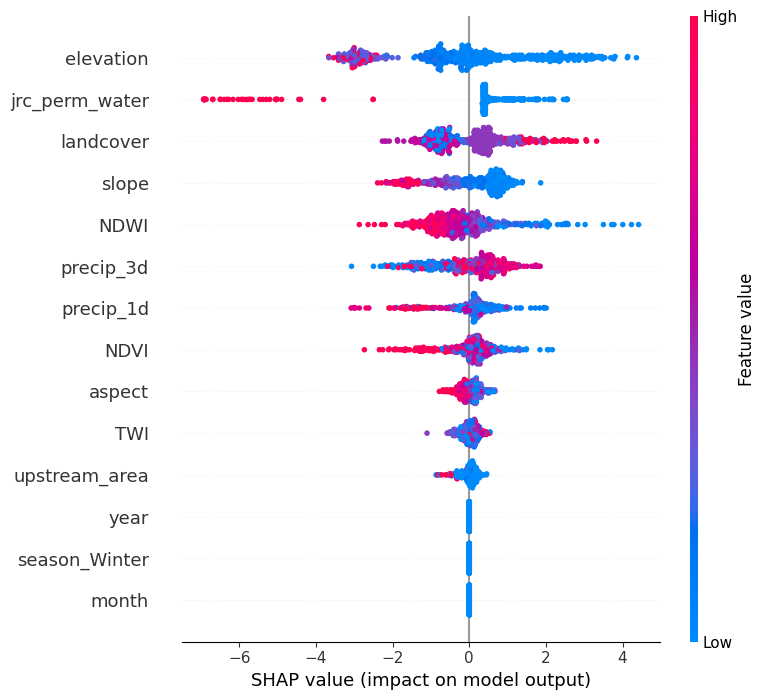

In [60]:
shap.summary_plot(
    shap_values,
    X_sample
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


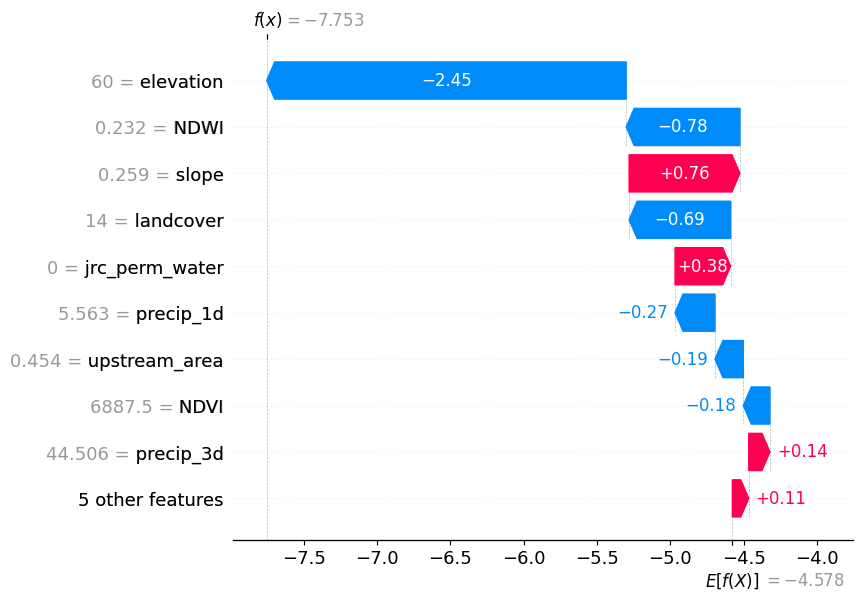

In [61]:
sample_data = X_test_C.iloc[[0]]

shap_value = explainer.shap_values(sample_data)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_value[0],
        base_values=explainer.expected_value,
        data=sample_data.iloc[0],
        feature_names=X_test_C.columns
    )
)

In [62]:
import pandas as pd

shap_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance": abs(shap_values).mean(axis=0)
})

shap_df.sort_values(
    "Importance",
    ascending=False
).head(10)

,Feature,Importance
6,elevation,1.480849
0,jrc_perm_water,1.027028
5,landcover,0.786534
7,slope,0.751593
4,NDWI,0.709842
2,precip_3d,0.673937
1,precip_1d,0.493996
3,NDVI,0.453717
8,aspect,0.187084
10,TWI,0.154297


In [63]:
sample = X_test_C.iloc[[0]]

# Flood probability
probability = model_C.predict_proba(sample)[0][1]

print("Flood Probability:", probability)

Flood Probability: 0.00042921149928138146


In [64]:
shap_values = explainer.shap_values(sample)

explanation = pd.DataFrame({
    "Feature": sample.columns,
    "Impact": shap_values[0]
})

explanation["Absolute Impact"] = abs(explanation["Impact"])

top_reasons = explanation.sort_values(
    "Absolute Impact",
    ascending=False
).head(5)

top_reasons

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,Feature,Impact,Absolute Impact
6,elevation,-2.451578,2.451578
4,NDWI,-0.775612,0.775612
7,slope,0.755680,0.755680
5,landcover,-0.692348,0.692348
0,jrc_perm_water,0.379022,0.379022


In [65]:
probability = model_C.predict_proba(sample)[0][1]

print("Flood Probability:", probability)

Flood Probability: 0.00042921149928138146


In [66]:
reasons_text = ""

feature_meaning = {
    "NDWI": "high water content or surface water presence",
    "NDVI": "vegetation condition affecting water absorption",
    "elevation": "terrain height affecting water accumulation",
    "landcover": "surface type affecting rainfall runoff",
    "year": "historical time pattern"
}


for _, row in top_reasons.iterrows():

    feature = row["Feature"]

    if row["Impact"] > 0:
        effect = "increases flood risk"
    else:
        effect = "reduces flood risk"

    meaning = feature_meaning.get(
        feature,
        "environmental condition"
    )

    reasons_text += (
        f"- {feature}: {meaning}, which {effect}\n"
    )


print(reasons_text)

- elevation: terrain height affecting water accumulation, which reduces flood risk
- NDWI: high water content or surface water presence, which reduces flood risk
- slope: environmental condition, which increases flood risk
- landcover: surface type affecting rainfall runoff, which reduces flood risk
- jrc_perm_water: environmental condition, which increases flood risk



In [67]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

nlp_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Model loaded")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded


In [68]:
report_input = f"""
Create a flood disaster report.

Flood probability: {probability:.2f}

Environmental analysis:
{reasons_text}

Include:

Risk Level:
Possible Reasons:
Safety Recommendations:
Emergency Actions:

Generate a complete report.
"""

In [69]:
inputs = tokenizer(
    report_input,
    return_tensors="pt",
    truncation=True
)

outputs = nlp_model.generate(
    **inputs,
    max_new_tokens=300
)

final_report = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(final_report)

Flood probability: 0.00 Environmental analysis: - elevation: terrain height affecting water accumulation, which reduces flood risk - NDWI: high water content or surface water presence, which reduces flood risk - slope: environmental condition, which increases flood risk - landcover: surface type affecting rainfall runoff, which reduces flood risk


In [70]:
import joblib

joblib.dump(model_C, "flood_prediction_model.pkl")

print("Model saved")

Model saved


In [71]:
joblib.dump(explainer, "shap_explainer.pkl")

['shap_explainer.pkl']

In [72]:
def predict_flood(input_data):

    probability = model_C.predict_proba(input_data)[0][1]

    if probability < 0.3:
        risk = "LOW"
    elif probability < 0.7:
        risk = "MEDIUM"
    else:
        risk = "HIGH"

    return probability, risk

In [73]:
probability, risk = predict_flood(sample)

print("Probability:", probability)
print("Risk:", risk)

Probability: 0.00042921149928138146
Risk: LOW


In [74]:
report = f"""
Flood Risk Assessment Report

Risk Level:
{risk}

Flood Probability:
{probability:.2f}

Main Factors:
{reasons_text}

Recommendations:
- Monitor rainfall conditions
- Maintain drainage systems
- Avoid construction near water channels

Emergency Actions:
- Issue warnings if risk increases
- Prepare evacuation routes
- Inform disaster management teams
"""

print(report)


Flood Risk Assessment Report

Risk Level:
LOW

Flood Probability:
0.00

Main Factors:
- elevation: terrain height affecting water accumulation, which reduces flood risk
- NDWI: high water content or surface water presence, which reduces flood risk
- slope: environmental condition, which increases flood risk
- landcover: surface type affecting rainfall runoff, which reduces flood risk
- jrc_perm_water: environmental condition, which increases flood risk


Recommendations:
- Monitor rainfall conditions
- Maintain drainage systems
- Avoid construction near water channels

Emergency Actions:
- Issue warnings if risk increases
- Prepare evacuation routes
- Inform disaster management teams



In [75]:
!pip install langchain chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found ex

In [76]:
import langchain
import chromadb
import sentence_transformers

print("All libraries working")

All libraries working


In [77]:
!pip install langchain-community langchain chromadb sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-adk 2.3.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.43.0 which is incompatible.
google-adk 2.3.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.43.0 which is incompatible.


In [78]:
import langchain_community

print("LangChain community installed")

LangChain community installed


/tmp/ipykernel_506/3202077662.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  import langchain_community


In [80]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("/content/Floodinfo.txt")

documents = loader.load()

print(documents)

[Document(metadata={'source': '/content/Floodinfo.txt'}, page_content='Floods occur when water exceeds the capacity of rivers,\ndrainage systems, or land absorption.\n\nHigh flood risk areas should monitor rainfall,\nwater levels, and evacuation warnings.\n\nPeople living in low lying areas should move to safer locations\nwhen authorities issue warnings.')]


In [81]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded")

/tmp/ipykernel_506/173910916.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded


In [82]:
from langchain_community.vectorstores import Chroma

vector_db = Chroma.from_documents(
    documents,
    embedding_model
)

print("Vector database created")

Vector database created


In [83]:
query = """
High flood risk due to rainfall and water accumulation.
What safety actions should be taken?
"""

results = vector_db.similarity_search(query, k=2)

for doc in results:
    print(doc.page_content)
    print("----------------")

Floods occur when water exceeds the capacity of rivers,
drainage systems, or land absorption.

High flood risk areas should monitor rainfall,
water levels, and evacuation warnings.

People living in low lying areas should move to safer locations
when authorities issue warnings.
----------------


In [84]:
# RAG retrieved information

query = f"""
Flood risk: {risk}
Flood probability: {probability:.2f}

Factors:
{reasons_text}

What safety actions are required?
"""


retrieved_docs = vector_db.similarity_search(
    query,
    k=3
)


rag_context = ""

for doc in retrieved_docs:
    rag_context += doc.page_content + "\n"


print(rag_context)

Floods occur when water exceeds the capacity of rivers,
drainage systems, or land absorption.

High flood risk areas should monitor rainfall,
water levels, and evacuation warnings.

People living in low lying areas should move to safer locations
when authorities issue warnings.



In [85]:
final_prompt = f"""
You are an AI disaster management assistant.

Create a flood risk assessment report.

Prediction Information:

Flood Probability:
{probability:.2f}

Risk Level:
{risk}

Machine Learning Explanation:
{reasons_text}


Retrieved Disaster Guidelines:
{rag_context}


Generate the report with exactly these sections:

Risk Level:
Explain why this risk level was predicted.

Possible Reasons:
Explain the environmental factors from the model.

Safety Recommendations:
Give practical prevention steps.

Emergency Actions:
Give actions for people and authorities.

Use the provided information.
Do not repeat the input directly.
Write a professional disaster report.
"""

print(final_prompt)


You are an AI disaster management assistant.

Create a flood risk assessment report.

Prediction Information:

Flood Probability:
0.00

Risk Level:
LOW

Machine Learning Explanation:
- elevation: terrain height affecting water accumulation, which reduces flood risk
- NDWI: high water content or surface water presence, which reduces flood risk
- slope: environmental condition, which increases flood risk
- landcover: surface type affecting rainfall runoff, which reduces flood risk
- jrc_perm_water: environmental condition, which increases flood risk



Retrieved Disaster Guidelines:
Floods occur when water exceeds the capacity of rivers,
drainage systems, or land absorption.

High flood risk areas should monitor rainfall,
water levels, and evacuation warnings.

People living in low lying areas should move to safer locations
when authorities issue warnings.



Generate the report with exactly these sections:

Risk Level:
Explain why this risk level was predicted.

Possible Reasons:
Expla